# Styling & gradients

`add_svg` lets you restyle a drawing at render time: forward matplotlib keywords
to every artist, override individual paths by their SVG `id`, drop paths entirely,
or desaturate the whole thing. This notebook also shows the best-effort gradient
support.

In [1]:
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt

import svg2mpl

In [3]:
FACE_SVG = """
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 100 100">
  <circle id="face" cx="50" cy="50" r="45" fill="#ffd54f" stroke="#5d4037" stroke-width="3"/>
  <circle id="eye_left"  cx="35" cy="40" r="6" fill="#3e2723"/>
  <circle id="eye_right" cx="65" cy="40" r="6" fill="#3e2723"/>
  <polyline id="mouth" points="32,65 50,78 68,65" fill="none"
            stroke="#3e2723" stroke-width="4"/>
</svg>
"""

In [4]:
def show(ax, title, **kwargs):
    svg2mpl.add_svg(FACE_SVG, ax=ax, **kwargs)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

## The starting drawing

A simple face made of a few ided shapes: `face`, `eye_left`, `eye_right`, and
`mouth`.

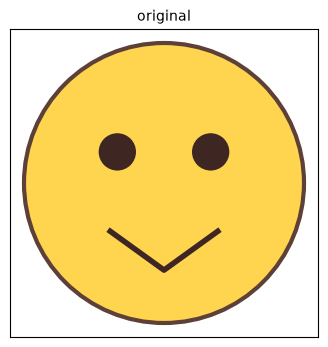

In [5]:
fig, ax = plt.subplots(figsize=(4, 4))
show(ax, "original")
plt.show()

## Global keywords, per-path overrides, exclude, grayscale

- **Global keywords** are forwarded to every artist (here a translucent black
  edge on everything).
- **`per_path_kwargs`** maps a property to a `{id: value}` dict to restyle
  individual elements.
- **`exclude`** takes regexes; matching ids are dropped.
- **`grayscale=True`** desaturates the fills.

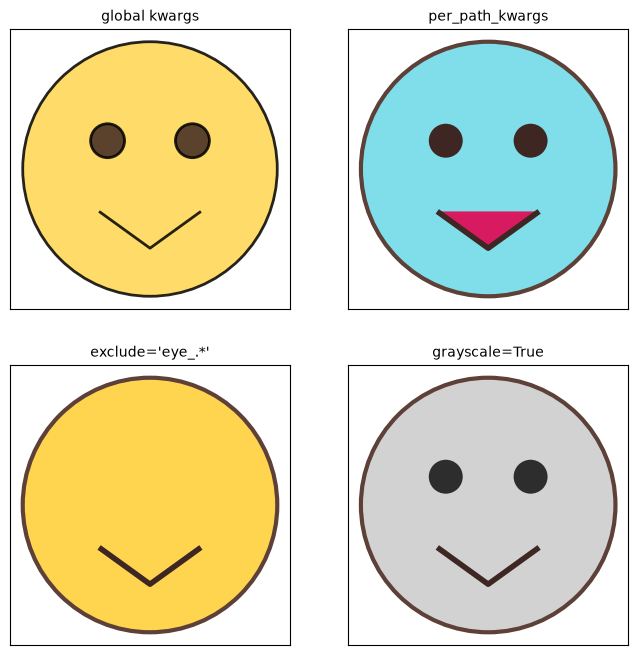

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

show(axes[0, 0], "global kwargs", edgecolor="black", linewidth=2, alpha=0.85)

show(axes[0, 1], "per_path_kwargs",
     per_path_kwargs={"facecolor": {"face": "#80deea", "mouth": "#d81b60"}})

show(axes[1, 0], "exclude='eye_.*'", exclude=r"eye_.*")

show(axes[1, 1], "grayscale=True", grayscale=True)

plt.show()

## Gradients

matplotlib has no native gradient fill, so `svg2mpl` approximates a
`linearGradient` by overlaying a clipped gradient image. It is best-effort but
captures the look for many drawings.

In [7]:
GRADIENT_SVG = """
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 100 100">
  <defs>
    <linearGradient id="sky" x1="0" y1="0" x2="0" y2="1">
      <stop offset="0%"  stop-color="#1a237e"/>
      <stop offset="100%" stop-color="#ff8a65"/>
    </linearGradient>
  </defs>
  <rect id="bg" x="0" y="0" width="100" height="100" fill="url(#sky)"/>
  <circle id="sun" cx="50" cy="70" r="18" fill="#fff59d"/>
</svg>
"""

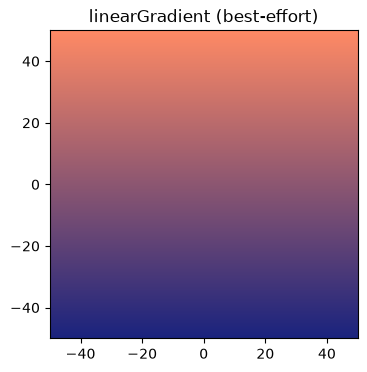

In [8]:
fig, ax = plt.subplots(figsize=(4, 4))
svg2mpl.add_svg(GRADIENT_SVG, ax=ax)
ax.set_aspect("equal")
ax.set_title("linearGradient (best-effort)")
plt.show()